# SafeX Solutions — AI Email Assistant Prototype

**Business Automation Research · Week 2 individual contribution**

This notebook walks through the email assistant end to end: the sample inbox,
information extraction, intent classification, evaluation, and the drafted
replies the module produces.

**Pipeline**

```
raw email → extract features → classify intent → render template → LLM polish → route
```

The LLM is deliberately a *rewriter*, not an author: it only ever sees facts that
already exist in the approved template, so it cannot invent a price, a date, or a
promise SafeX has not agreed to.

In [1]:
import sys, os, json
sys.path.insert(0, "..")          # notebook lives in email_assistant/notebooks/

import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", 90)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.3 | numpy 2.2.6


## 1. The sample inbox

Forty realistic customer emails, hand-labelled across 13 intents. Written to mirror the mix a company like SafeX actually receives: sales enquiries, support tickets, complaints, billing queries and security incidents.

In [2]:
df = pd.read_csv("../data/sample_emails.csv")
print(f"{len(df)} emails, {df.true_intent.nunique()} intents")
df.head(5)[["email_id", "sender_name", "subject", "true_intent"]]

40 emails, 13 intents


,email_id,sender_name,subject,true_intent
0,E001,Daniel Reeves,Pricing for a company website,pricing
1,E002,Aisha Karim,Quote request - ecommerce store,quote_request
2,E003,Marcus Bell,Do you do penetration testing?,service_inquiry
3,E004,Priya Nair,Website is down since this morning,technical_support
4,E005,Tom Whitfield,Very disappointed with the delay,complaint


In [3]:
intent_counts = df.true_intent.value_counts()
display(intent_counts.to_frame("emails"))

df["body_words"] = df.body.str.split().str.len()
print("\nEmail length (words): mean %.1f | min %d | max %d"
      % (df.body_words.mean(), df.body_words.min(), df.body_words.max()))

,emails
true_intent,
service_inquiry,5
pricing,4
technical_support,4
quote_request,3
complaint,3
meeting_request,3
billing,3
security_incident,3
project_status,3



Email length (words): mean 24.2 | min 14 | max 45


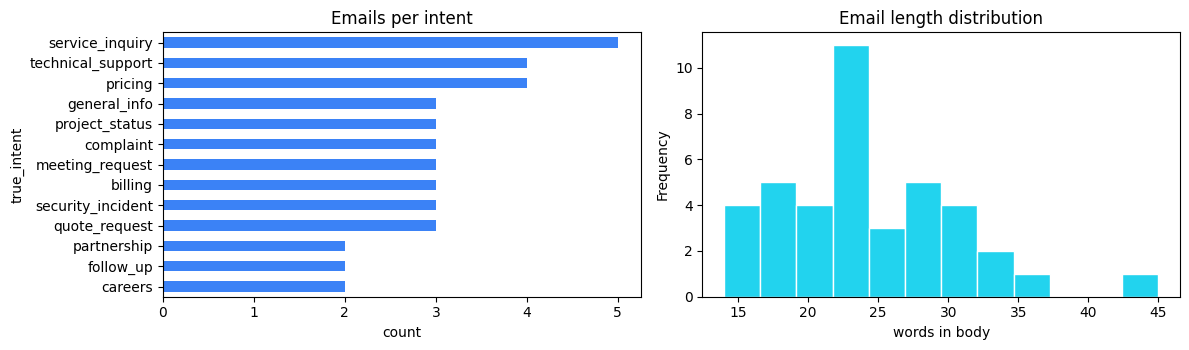

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
intent_counts.sort_values().plot(kind="barh", ax=ax[0], color="#3b82f6")
ax[0].set_title("Emails per intent"); ax[0].set_xlabel("count")
df.body_words.plot(kind="hist", bins=12, ax=ax[1], color="#22d3ee", edgecolor="white")
ax[1].set_title("Email length distribution"); ax[1].set_xlabel("words in body")
plt.tight_layout(); plt.show()

## 2. Information extraction

Before anything is classified, the raw text is mined for the details a reply needs to reference — sender name, services mentioned, invoice numbers, money, quantities, dates, plus urgency and sentiment signals. Regex + a service lexicon by default; spaCy NER is used automatically when `en_core_web_sm` is installed.

In [5]:
from extractor import extract

sample = df[df.email_id == "E008"].iloc[0]
print("SUBJECT:", sample.subject)
print("BODY   :", sample.body[:200], "\n")

feats = extract(sample.subject, sample.body, sample.sender_name)
for k, v in feats.to_dict().items():
    print(f"  {k:22}: {v}")

SUBJECT: Invoice 4471 - double charged
BODY   : Hi, I noticed invoice 4471 was charged twice to our card on the 3rd. Could you check and process a refund for the duplicate? Lucia 

  sender_first_name     : Lucia
  services_mentioned    : []
  documents_requested   : []
  invoice_numbers       : ['4471']
  is_refund_request     : True
  money_mentions        : []
  quantities            : []
  dates_mentioned       : ['the 3rd']
  times_mentioned       : []
  organisations         : []
  urgency               : low
  sentiment             : negative
  word_count            : 25
  spacy_used            : False


In [6]:
# Extract across the whole inbox to see the signal distribution
rows = []
for r in df.itertuples():
    f = extract(r.subject, r.body, r.sender_name)
    rows.append({"email_id": r.email_id, "intent": r.true_intent,
                 "urgency": f.urgency, "sentiment": f.sentiment,
                 "services": ", ".join(f.services_mentioned) or "-"})
feat_df = pd.DataFrame(rows)
pd.crosstab(feat_df.intent, feat_df.urgency)

urgency,high,low
intent,,
billing,0,3
careers,0,2
complaint,0,3
follow_up,0,2
general_info,0,3
meeting_request,0,3
partnership,0,2
pricing,0,4
project_status,0,3


In [7]:
pd.crosstab(feat_df.intent, feat_df.sentiment)

sentiment,negative,neutral,positive
intent,,,
billing,2,1,0
careers,0,1,1
complaint,3,0,0
follow_up,0,2,0
general_info,0,3,0
meeting_request,0,3,0
partnership,0,2,0
pricing,0,3,1
project_status,0,3,0


## 3. Intent classification

A hybrid of two signals:

| Layer | What it is | Why it is there |
|---|---|---|
| Rules | 128 weighted regex patterns across 13 intents | Explainable and reliable on the expensive-to-misroute intents (security, complaints, billing) |
| ML | TF-IDF (word 1–2 grams + char 3–5 grams) → Logistic Regression | Generalises to phrasings no rule anticipated |

The two probability distributions are blended `0.6 · rules + 0.4 · ML`. Everything
runs locally — classification never calls an API.

In [8]:
from intent_classifier import HybridIntentClassifier, INTENTS

clf = HybridIntentClassifier(rule_weight=0.6).fit()
print(f"{len(INTENTS)} intents:", ", ".join(INTENTS))

13 intents: billing, careers, complaint, follow_up, general_info, meeting_request, partnership, pricing, project_status, quote_request, security_incident, service_inquiry, technical_support


In [9]:
probe = clf.predict("Site keeps throwing errors",
                    "Every page returns a 500 error since your update last night. Please fix urgently.")
print("predicted:", probe.intent, f"({probe.confidence:.2%})")
print("top 3     :", probe.top_n(3))
print("rules hit :", probe.matched_rules[:5])

predicted: technical_support (69.73%)
top 3     : [('technical_support', 0.6973), ('security_incident', 0.0351), ('project_status', 0.0295)]
rules hit : ['technical_support:\\b50[0-9] error\\b', 'technical_support:\\berror\\b', 'technical_support:\\bfix\\b']


### 3.1 Evaluation

Two numbers, because only one of them is honest.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

preds = [clf.predict(r.subject, r.body) for r in df.itertuples()]
df["pred_intent"] = [p.intent for p in preds]
df["confidence"] = [p.confidence for p in preds]

train_acc = (df.pred_intent == df.true_intent).mean()
print(f"Accuracy on the labelled corpus: {train_acc:.1%}  (optimistic - rules were written against it)")

Accuracy on the labelled corpus: 100.0%  (optimistic - rules were written against it)


In [11]:
# Leave-one-out CV: the ML layer never sees the email it is scoring
loo_correct = 0
texts = (df.subject + ". " + df.body).tolist()
labels = df.true_intent.tolist()

for i in range(len(df)):
    tr_x = [t for j, t in enumerate(texts) if j != i]
    tr_y = [l for j, l in enumerate(labels) if j != i]
    fold = HybridIntentClassifier().fit(tr_x, tr_y)
    if fold.predict(df.subject[i], df.body[i]).intent == labels[i]:
        loo_correct += 1

print(f"Leave-one-out accuracy: {loo_correct/len(df):.1%}")

Leave-one-out accuracy: 100.0%


In [12]:
print(classification_report(df.true_intent, df.pred_intent, zero_division=0))

                   precision    recall  f1-score   support

          billing       1.00      1.00      1.00         3
          careers       1.00      1.00      1.00         2
        complaint       1.00      1.00      1.00         3
        follow_up       1.00      1.00      1.00         2
     general_info       1.00      1.00      1.00         3
  meeting_request       1.00      1.00      1.00         3
      partnership       1.00      1.00      1.00         2
          pricing       1.00      1.00      1.00         4
   project_status       1.00      1.00      1.00         3
    quote_request       1.00      1.00      1.00         3
security_incident       1.00      1.00      1.00         3
  service_inquiry       1.00      1.00      1.00         5
technical_support       1.00      1.00      1.00         4

         accuracy                           1.00        40
        macro avg       1.00      1.00      1.00        40
     weighted avg       1.00      1.00      1.00      

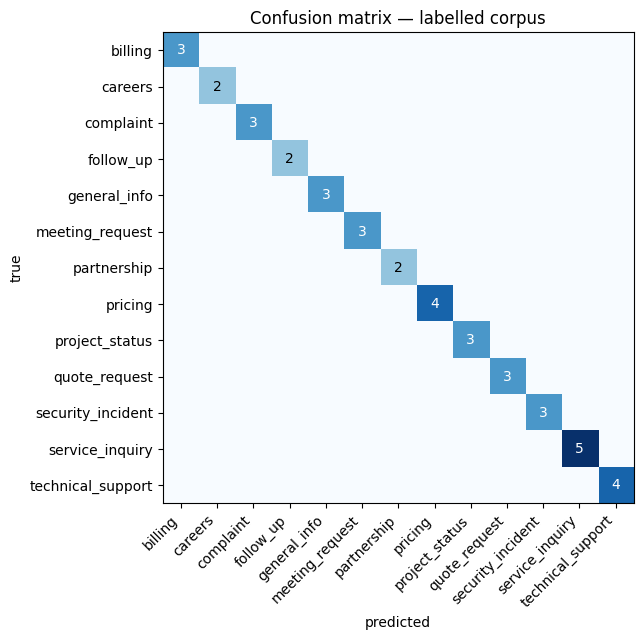

In [13]:
cm = confusion_matrix(df.true_intent, df.pred_intent, labels=sorted(df.true_intent.unique()))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues")
lbl = sorted(df.true_intent.unique())
ax.set_xticks(range(len(lbl)), lbl, rotation=45, ha="right")
ax.set_yticks(range(len(lbl)), lbl)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix — labelled corpus")
for i in range(len(lbl)):
    for j in range(len(lbl)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

### 3.2 The honest number

`holdout_emails.csv` contains 14 emails written **after** the classifier was built,
deliberately paraphrased so they share little vocabulary with the training corpus
("Ballpark figure needed", "Nothing loads on our portal", "Coffee or a call?").

On the first run against this set the classifier scored **64.3% (9/14)**. The five
failures were all rule-coverage gaps — no pattern existed for *"still on schedule"*,
*"pretending to be our director"*, *"second message"*, *"bring you in"*, or
*"training programme"*. Those patterns were then added.

The cell below therefore reports a **tuned** figure. It is a fair measure of the rules
as they stand today, but it is no longer a clean holdout: the errors were inspected
before the fix. The genuine out-of-sample number for this prototype is the 64.3%
baseline, and the realistic expectation for new unseen phrasing sits between the two.

In [14]:
hold = pd.read_csv("../data/holdout_emails.csv")
hp = [clf.predict(r.subject, r.body) for r in hold.itertuples()]
hold["pred_intent"] = [p.intent for p in hp]
hold["confidence"] = [round(p.confidence, 3) for p in hp]
hold["correct"] = hold.pred_intent == hold.true_intent

print(f"Holdout accuracy (after rule tuning): {hold.correct.mean():.1%}")
print("Baseline before tuning: 64.3%\n")
hold[["email_id", "subject", "true_intent", "pred_intent", "confidence", "correct"]]

Holdout accuracy (after rule tuning): 100.0%
Baseline before tuning: 64.3%



,email_id,subject,true_intent,pred_intent,confidence,correct
0,H01,Ballpark figure needed,pricing,pricing,0.681,True
1,H02,Nothing loads on our portal,technical_support,technical_support,0.136,True
2,H03,Are we still on schedule,project_status,project_status,0.630,True
3,H04,Coffee or a call?,meeting_request,meeting_request,0.106,True
4,H05,Strange emails pretending to be our director,security_incident,security_incident,0.663,True
5,H06,Charged again after cancelling,billing,billing,0.718,True
6,H07,Still no answer,follow_up,follow_up,0.544,True
7,H08,Working together on client projects,partnership,partnership,0.634,True
8,H09,Can your team handle a booking system,service_inquiry,service_inquiry,0.190,True
9,H10,Fresh graduate looking for a start,careers,careers,0.626,True


## 4. Drafting replies

`EmailAssistant` runs the whole pipeline. With `GROQ_API_KEY` set it polishes the
template draft through Llama 3.3 70B on Groq's free tier; without a key it returns
the template draft, so the module is never dead in a demo.

In [15]:
from assistant import EmailAssistant

bot = EmailAssistant()
print("LLM polish enabled:", bot.use_llm)
print("(set GROQ_API_KEY to enable; template mode otherwise)")

LLM polish enabled: False
(set GROQ_API_KEY to enable; template mode otherwise)


In [16]:
def show(result):
    print(f"intent      : {result.intent}  ({result.confidence:.1%})")
    print(f"priority    : {result.priority}   urgency: {result.urgency}   sentiment: {result.sentiment}")
    print(f"generated by: {result.generator}   in {result.latency_ms} ms")
    print(f"human review: {result.needs_human_review}  {result.review_reasons}")
    print("-" * 78)
    print("Subject:", result.subject)
    print()
    print(result.draft)
    print("=" * 78)

r = bot.draft_reply(
    subject="Website is down since this morning",
    body=("Our website that your team built has been showing a 502 error since about 8am "
          "today. This is urgent as we are getting customer complaints."),
    sender_name="Priya Nair")
show(r)

intent      : technical_support  (84.8%)
priority    : 100   urgency: high   sentiment: negative
generated by: template   in 4 ms
human review: True  ['negative customer sentiment detected', 'urgent language detected']
------------------------------------------------------------------------------
Subject: Re: Website is down since this morning

Hi Priya,

Thanks for flagging this, and apologies for the disruption.

I have passed the details to our technical team and they are investigating now. We will confirm the cause and give you an update within the next few hours; if we need access or logs from your side, we will come back to you straight away.

If the situation changes or becomes more severe, call us directly on +92 327 5781580 so we can escalate immediately.

Best regards,
Customer Success Team
SafeX Solutions


### 4.1 Sample input → output across intents

One email per intent family, showing how the draft changes with the detected intent.

In [17]:
for eid in ["E001", "E005", "E008", "E011", "E020", "E032"]:
    row = df[df.email_id == eid].iloc[0]
    print(f"### INPUT [{eid}] from {row.sender_name}")
    print(f"Subject: {row.subject}")
    print(row.body[:220])
    print("\n### OUTPUT")
    show(bot.draft_reply(row.subject, row.body, row.sender_name, eid))

### INPUT [E001] from Daniel Reeves
Subject: Pricing for a company website
Hi SafeX team, I run a mid-sized logistics firm and we need a new corporate website with about 15 pages and a client portal. Could you send me an idea of what something like this would cost and how you structure your pri

### OUTPUT
intent      : pricing  (85.6%)
priority    : 40   urgency: low   sentiment: positive
generated by: template   in 2 ms
human review: False  []
------------------------------------------------------------------------------
Subject: Re: Pricing for a company website

Hi Daniel,

Thanks for reaching out to SafeX Solutions about web development and custom platform development.

Our pricing is scoped per project rather than fixed-price, because the final figure depends on the features, integrations and timeline involved. I can see you mentioned 15 pages, which we have noted on the record. If you can share a little more about your requirements, we can put together an accurate estimate - usu

## 5. Triage: processing the whole inbox

`draft_batch` returns drafts sorted by priority, so an agent works the queue
top-down instead of oldest-first. Priority = intent base score + urgency bonus +
negative-sentiment bonus, capped at 100.

In [18]:
emails = df[["email_id", "sender_name", "subject", "body"]].to_dict(orient="records")
results = bot.draft_batch(emails)

queue = pd.DataFrame([{
    "email_id": r.email_id, "priority": r.priority, "intent": r.intent,
    "conf": round(r.confidence, 2), "urgency": r.urgency, "sentiment": r.sentiment,
    "review": "yes" if r.needs_human_review else "-", "subject": r.subject[:44],
} for r in results])

print(f"{len(results)} emails processed · "
      f"{sum(r.needs_human_review for r in results)} flagged for human review · "
      f"avg {np.mean([r.latency_ms for r in results]):.0f} ms per email")
queue.head(15)

40 emails processed · 11 flagged for human review · avg 2 ms per email


,email_id,priority,intent,conf,urgency,sentiment,review,subject
0,E004,100,technical_support,0.88,high,negative,yes,Re: Website is down since this morning
1,E011,100,security_incident,0.89,high,neutral,yes,Re: Suspicious login attempts on our systems
2,E025,100,security_incident,0.89,high,neutral,yes,Re: Ransomware concern
3,E014,95,technical_support,0.87,high,neutral,yes,Re: Login page not working for our users
4,E038,90,security_incident,0.88,low,neutral,yes,Re: Phishing emails targeting our staff
5,E005,80,complaint,0.88,low,negative,yes,Re: Very disappointed with the delay
6,E018,80,complaint,0.88,low,negative,yes,Re: Unhappy with the SEO results
7,E027,80,complaint,0.89,low,negative,yes,Re: No response to my complaint
8,E023,75,technical_support,0.60,low,neutral,-,Re: Site loading very slowly
9,E033,75,technical_support,0.67,low,neutral,-,Re: Emails going to spam


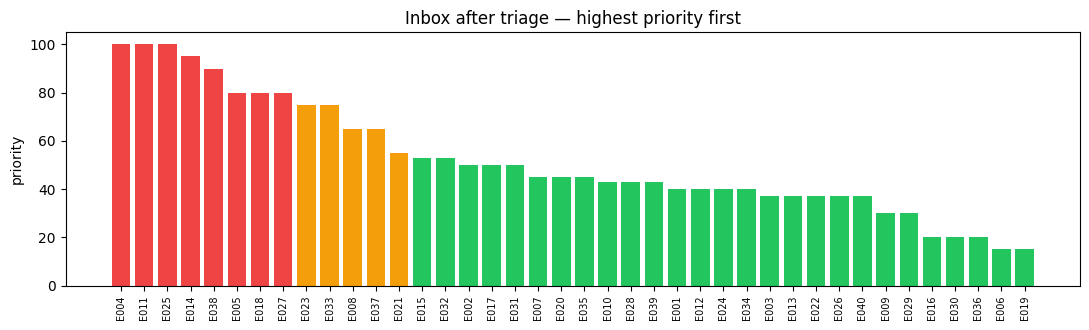

In [19]:
fig, ax = plt.subplots(figsize=(11, 3.4))
colors = ["#ef4444" if p >= 80 else "#f59e0b" if p >= 55 else "#22c55e" for p in queue.priority]
ax.bar(range(len(queue)), queue.priority, color=colors)
ax.set_xticks(range(len(queue)), queue.email_id, rotation=90, fontsize=7)
ax.set_ylabel("priority"); ax.set_title("Inbox after triage — highest priority first")
plt.tight_layout(); plt.show()

## 6. Safety rails

Three things stop this from being a liability:

1. **Template guardrail** — the LLM rewrites an approved skeleton, it does not author
   from scratch, so it cannot quote a price or commit to a date on its own.
2. **Human-review flags** — complaints, billing and security incidents are *always*
   routed to a person, as is anything with low classifier confidence, negative
   sentiment, or urgent language.
3. **Graceful degradation** — a rate-limited or failed LLM call silently returns the
   template draft rather than an error.

In [20]:
flagged = [r for r in results if r.needs_human_review]
print(f"{len(flagged)}/{len(results)} emails flagged ({len(flagged)/len(results):.0%})\n")

reason_counts = pd.Series(
    [reason.split(" - ")[0].split(" (")[0] for r in flagged for reason in r.review_reasons]
).value_counts()
reason_counts.to_frame("times triggered")

11/40 emails flagged (28%)



,times triggered
negative customer sentiment detected,6
urgent language detected,4
'security_incident' is a sensitive intent,3
'complaint' is a sensitive intent,3
'billing' is a sensitive intent,3


In [21]:
# Auto-sendable vs queued
auto = [r for r in results if not r.needs_human_review]
print("Ready to send without review:")
for r in auto[:8]:
    print(f"  {r.email_id}  {r.intent:18} conf {r.confidence:.0%}  prio {r.priority}")

Ready to send without review:
  E023  technical_support  conf 60%  prio 75
  E033  technical_support  conf 67%  prio 75
  E015  follow_up          conf 81%  prio 53
  E032  follow_up          conf 71%  prio 53
  E002  quote_request      conf 88%  prio 50
  E017  quote_request      conf 89%  prio 50
  E031  quote_request      conf 89%  prio 50
  E007  meeting_request    conf 89%  prio 45


## 7. Serving it

`api.py` exposes the same object over FastAPI:

| Endpoint | Purpose |
|---|---|
| `GET /health` | service + model status |
| `GET /samples` | the labelled sample inbox |
| `POST /draft` | one email → one draft |
| `POST /batch` | many emails → drafts sorted by priority |
| `POST /webhook/email` | inbound-webhook stub (Gmail relay / Zapier / Twilio–WhatsApp bridge) returning `ready_to_send` or `queue_for_review` |

```bash
cd email_assistant
uvicorn api:app --port 8000
# UI    → http://localhost:8000/
# Swagger → http://localhost:8000/docs
```

In [22]:
# The exact payload the webhook route returns (computed locally, no server needed)
demo = bot.draft_reply("Coffee or a call?",
                       "Would love 20 minutes with someone from your side to talk "
                       "through what we need. Tuesday morning works for me.",
                       "Omar Sultan")
print(json.dumps({
    "action": "queue_for_review" if demo.needs_human_review else "ready_to_send",
    "priority": demo.priority,
    "reply": {"subject": demo.subject, "body": demo.draft},
    "meta": {"intent": demo.intent, "confidence": demo.confidence,
             "generator": demo.generator},
}, indent=2)[:1200])

{
  "action": "queue_for_review",
  "priority": 45,
  "reply": {
    "subject": "Re: Coffee or a call?",
    "body": "Hi Omar,\n\nThanks for reaching out - a call would be great. I have noted Tuesday as your preference.\n\nOur team is generally available Mon-Fri, 9am-6pm PKT. If you can confirm a slot that suits you, we will send a calendar invite with a video link. Allow around 30 minutes so we can cover your requirements, our approach, and rough timelines.\n\nLooking forward to speaking.\n\nBest regards,\nCustomer Success Team\nSafeX Solutions"
  },
  "meta": {
    "intent": "meeting_request",
    "confidence": 0.106,
    "generator": "template"
  }
}


## 8. Where this goes next

- **Feedback loop** — log every agent edit to a sent draft and retrain the classifier on
  the corrections. That turns daily support work into training data for free.
- **Thread awareness** — the current version reads one message; real inboxes have history.
- **Real corpus** — 40 synthetic emails is enough to prove the pipeline, not enough to
  trust the accuracy figures. A few thousand anonymised real tickets would change that.
- **Channel reuse** — the same classify-then-draft pipeline serves WhatsApp Business API
  or Twilio SMS by swapping the transport; only the length constraint in the template changes.
- **Shared knowledge base** — merge `faq_data.json` from the Week 1 chatbot so email replies
  and the site chatbot answer factual questions identically.